# 🔄 Hourly Weather Model Monitoring & Retraining Strategy

## 🎯 Objective
Implement a **comprehensive monitoring system** to detect performance degradation **over time** and determine when retraining is necessary for the 5-day temperature forecasting models trained on hourly-enhanced data.

## 🔧 Key Monitoring Components

1. **Time-Series Performance Tracking** - Monitor R² and RMSE degradation **day-by-day**
2. **Cumulative Degradation Analysis** - Track how performance declines from Day 1 → Day 2 → Day 3 → ... 
3. **Automated Decision Logic** - Smart thresholds based on accumulated degradation
4. **Visual Dashboard** - Interactive charts showing model health trends over time
5. **Retraining Timeline** - Clear timeline showing when to retrain based on degradation velocity

## 📊 What We Monitor

- **R² Score Over Time**: Track how R² decreases from deployment day to current day
- **RMSE Growth Over Time**: Monitor prediction error increase day-by-day
- **Degradation Rate**: Calculate how fast performance is declining (% per day/week)
- **Time Since Deployment**: Days/weeks/months since last training
- **Cumulative Degradation**: Total performance loss from initial deployment

## ⚠️ Retraining Thresholds (Time-Based Degradation)

**The key insight**: Models degrade gradually over time. We track **when** degradation reaches critical levels.

### **Monitoring Timeline** (Days Since Deployment)

| Days Since Training | Expected R² Loss | Urgency Level | Action |
|---------------------|------------------|---------------|--------|
| **0-7 days** | < 2% | ✅ Fresh | Normal operation |
| **7-14 days** | 2-5% | 🟢 Healthy | Continue monitoring |
| **14-21 days** | 5-8% | 🟡 Early Warning | Plan retraining |
| **21-30 days** | 8-10% | 🟠 Moderate | Schedule retraining |
| **30-45 days** | 10-12% | ⚠️ High Priority | Urgent retraining |
| **45-60 days** | 12-15% | 🔴 Critical | Immediate action |
| **> 60 days** | ≥ 15% | ? Emergency | Stop predictions |

### **Degradation Velocity Thresholds**

- **< 0.5% per week**: Slow degradation - monitor routinely
- **0.5-1% per week**: Normal degradation - plan retraining in 4-6 weeks
- **1-2% per week**: Fast degradation - retrain within 2-3 weeks
- **> 2% per week**: Critical degradation - immediate retraining needed

## 🎯 Core Concept: Time-Based Monitoring

**Unlike comparing to baseline**, we track:

```
Day 1 (Deployment):     R² = 0.95  (Baseline)
Day 7 (1 week later):   R² = 0.94  (Loss: 1.1%)  ✅ Healthy
Day 14 (2 weeks later): R² = 0.93  (Loss: 2.1%)  🟢 Continue
Day 21 (3 weeks later): R² = 0.91  (Loss: 4.2%)  🟡 Plan retraining
Day 30 (1 month later): R² = 0.88  (Loss: 7.4%)  🟠 Schedule retraining
Day 45 (1.5 months):    R² = 0.85  (Loss: 10.5%) ⚠️ Urgent
Day 60 (2 months):      R² = 0.81  (Loss: 14.7%) 🔴 Critical - RETRAIN NOW
```

**Degradation velocity**: (14.7% / 60 days) = 0.245% per day = **1.7% per week** → Fast degradation

---

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import ks_2samp
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import RobustScaler
import joblib
import json
import os
import sys
from datetime import datetime, timedelta

# Visualization libraries
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("✅ Libraries loaded successfully")
print("📊 Ready to monitor 5-day temperature forecasting models (hourly-enhanced)")
print("🎯 Focus: Multi-horizon monitoring (Day 1 through Day 5)")

✅ Libraries loaded successfully
📊 Ready to monitor 5-day temperature forecasting models (hourly-enhanced)
🎯 Focus: Multi-horizon monitoring (Day 1 through Day 5)


## 1️⃣ Load Trained Models and Baseline Performance

In [2]:
# Load trained models and establish baseline performance
print("📂 LOADING TRAINED MODELS & METADATA")
print("=" * 45)

models_dir = '../models/hourly_trained'

try:
    # Load model metadata from notebook 03
    with open(f'{models_dir}/model_metadata.json', 'r') as f:
        model_metadata = json.load(f)
    
    print("✅ Model metadata loaded")
    
    # Extract baseline performance for all 5 horizons
    baseline_performance = {}
    best_models_info = model_metadata['best_models']
    
    for horizon_name, model_info in best_models_info.items():
        baseline_performance[horizon_name] = {
            'model_name': model_info['model_name'],
            'model_file': model_info['model_file'],
            'r2': model_info['test_r2'],
            'rmse': model_info['test_rmse'],
            'mae': model_info['test_mae']
        }
        print(f"   • {horizon_name}: {model_info['model_name']:18} R²={model_info['test_r2']:.4f}, RMSE={model_info['test_rmse']:.3f}°C")
    
    # Load the trained models
    trained_models = {}
    for horizon_name, model_info in best_models_info.items():
        model_path = f"{models_dir}/{model_info['model_file']}"
        trained_models[horizon_name] = joblib.load(model_path)
        print(f"   ✅ {horizon_name} model loaded: {model_info['model_file']}")
    
    # Load feature columns and scaler
    feature_columns = joblib.load(f'{models_dir}/feature_columns_5day.joblib')
    scaler = joblib.load(f'{models_dir}/scaler_5day.joblib')
    
    print(f"\n✅ All models loaded successfully!")
    print(f"   • Total horizons: {len(trained_models)}")
    print(f"   • Features: {len(feature_columns)}")
    print(f"   • Scaler: RobustScaler loaded")
    
    # Display best overall model
    best_overall = model_metadata['best_overall_model']
    print(f"\n🏆 Best Overall Model (Avg across 5 days):")
    print(f"   • Model: {best_overall['model_name']}")
    print(f"   • Avg R²: {best_overall['avg_r2']:.4f}")
    print(f"   • Avg RMSE: {best_overall['avg_rmse']:.3f}°C")

except FileNotFoundError:
    print("❌ Error: Model files not found.")
    print("   Please run notebook 03_model_training_hourly.ipynb first.")
    raise
except Exception as e:
    print(f"❌ Error loading models: {e}")
    raise

📂 LOADING TRAINED MODELS & METADATA
✅ Model metadata loaded
   • day_1: XGBoost            R²=0.9369, RMSE=1.299°C
   • day_2: LightGBM           R²=0.8525, RMSE=1.988°C
   • day_3: XGBoost            R²=0.8074, RMSE=2.271°C
   • day_4: XGBoost            R²=0.7799, RMSE=2.428°C
   • day_5: XGBoost            R²=0.7701, RMSE=2.482°C
   ✅ day_1 model loaded: best_model_day_1_xgboost.joblib
   ✅ day_2 model loaded: best_model_day_2_lightgbm.joblib
   ✅ day_3 model loaded: best_model_day_3_xgboost.joblib
   ✅ day_4 model loaded: best_model_day_4_xgboost.joblib
   ✅ day_5 model loaded: best_model_day_5_xgboost.joblib

✅ All models loaded successfully!
   • Total horizons: 5
   • Features: 91
   • Scaler: RobustScaler loaded

🏆 Best Overall Model (Avg across 5 days):
   • Model: XGBoost
   • Avg R²: 0.8293
   • Avg RMSE: 2.094°C


## 2️⃣ Time-Based Model Monitor Class

This monitoring class tracks performance **over time** (day-by-day) and calculates cumulative degradation from deployment date.

In [3]:
class TimeBasedModelMonitor:
    """
    Time-based monitoring for 5-day temperature forecasting models.
    Tracks performance degradation over time (day-by-day, week-by-week).
    
    Key concept: Models degrade gradually. We track WHEN degradation reaches critical levels.
    """
    
    def __init__(self, models_dict, feature_columns, scaler, baseline_performance, deployment_date=None):
        self.models = models_dict
        self.feature_columns = feature_columns
        self.scaler = scaler
        self.baseline_performance = baseline_performance
        self.deployment_date = deployment_date or datetime.now()
        
        # Initialize performance history with deployment baseline
        self.performance_history = {f'day_{i}': [] for i in range(1, 6)}
        
        # Store initial baseline as Day 0
        for horizon_name, baseline in baseline_performance.items():
            self.performance_history[horizon_name].append({
                'monitoring_day': 0,
                'calendar_date': self.deployment_date,
                'days_since_training': 0,
                'r2': baseline['r2'],
                'rmse': baseline['rmse'],
                'mae': baseline['mae'],
                'cumulative_r2_loss': 0.0,
                'cumulative_r2_loss_pct': 0.0,
                'degradation_velocity_per_day': 0.0,
                'degradation_velocity_per_week': 0.0
            })
        
        # Time-based degradation thresholds
        self.thresholds = {
            # R² cumulative loss thresholds (percentage)
            'r2_loss_minimal': 2.0,      # 0-2% loss = fresh/healthy
            'r2_loss_low': 5.0,          # 2-5% loss = early warning
            'r2_loss_medium': 8.0,       # 5-8% loss = moderate concern
            'r2_loss_high': 10.0,        # 8-10% loss = high priority
            'r2_loss_critical': 12.0,    # 10-12% loss = critical
            'r2_loss_emergency': 15.0,   # ≥12% loss = emergency
            
            # Degradation velocity thresholds (% per week)
            'velocity_slow': 0.5,        # < 0.5% per week = slow
            'velocity_normal': 1.0,      # 0.5-1% per week = normal
            'velocity_fast': 2.0,        # 1-2% per week = fast
            'velocity_critical': 3.0,    # > 2% per week = critical
            
            # Time thresholds (days since training)
            'time_fresh': 7,             # 0-7 days = fresh
            'time_healthy': 14,          # 7-14 days = healthy
            'time_warning': 21,          # 14-21 days = early warning
            'time_moderate': 30,         # 21-30 days = moderate
            'time_high': 45,             # 30-45 days = high priority
            'time_critical': 60          # 45-60 days = critical
        }
        
        print(f"⏰ Time-Based Monitor Initialized:")
        print(f"   • Deployment date: {self.deployment_date.strftime('%Y-%m-%d')}")
        print(f"   • Horizons tracked: {list(self.models.keys())}")
        print(f"   • Features: {len(feature_columns)}")
        print(f"   • Monitoring approach: Day-by-day degradation tracking")
    
    def evaluate_horizon_performance(self, horizon_name, X_period, y_period, monitoring_info):
        """Evaluate model performance and track degradation over time."""
        try:
            model = self.models[horizon_name]
            baseline = self.baseline_performance[horizon_name]
            
            # Get previous performance (for velocity calculation)
            history = self.performance_history[horizon_name]
            previous_perf = history[-1] if history else None
            
            # Make predictions
            y_pred = model.predict(X_period)
            
            # Calculate metrics
            rmse = np.sqrt(mean_squared_error(y_period, y_pred))
            mae = mean_absolute_error(y_period, y_pred)
            r2 = r2_score(y_period, y_pred)
            
            # Calculate time-based metrics
            days_since_training = monitoring_info['days_since_training']
            monitoring_day = len(history)  # 0-indexed (0 = deployment)
            
            # Calculate cumulative R² loss from baseline
            baseline_r2 = baseline['r2']
            r2_loss = baseline_r2 - r2  # Absolute loss
            r2_loss_pct = (r2_loss / baseline_r2) * 100  # Percentage loss
            
            # Calculate degradation velocity
            if previous_perf and days_since_training > 0:
                days_elapsed = days_since_training - previous_perf['days_since_training']
                if days_elapsed > 0:
                    r2_change = previous_perf['r2'] - r2
                    velocity_per_day = (r2_change / baseline_r2) * 100 / days_elapsed
                    velocity_per_week = velocity_per_day * 7
                else:
                    velocity_per_day = 0.0
                    velocity_per_week = 0.0
            else:
                velocity_per_day = 0.0
                velocity_per_week = 0.0
            
            performance_data = {
                'horizon': horizon_name,
                'monitoring_day': monitoring_day,
                'calendar_date': monitoring_info['calendar_date'],
                'days_since_training': days_since_training,
                'sample_count': monitoring_info['sample_count'],
                'r2': r2,
                'rmse': rmse,
                'mae': mae,
                'baseline_r2': baseline_r2,
                'baseline_rmse': baseline['rmse'],
                'cumulative_r2_loss': r2_loss,
                'cumulative_r2_loss_pct': r2_loss_pct,
                'degradation_velocity_per_day': velocity_per_day,
                'degradation_velocity_per_week': velocity_per_week,
                'baseline_model': baseline['model_name']
            }
            
            self.performance_history[horizon_name].append(performance_data)
            return performance_data
            
        except Exception as e:
            print(f"⚠️ Error evaluating {horizon_name}: {str(e)}")
            return None
    
    def evaluate_all_horizons(self, X_period, y_targets_dict, monitoring_info):
        """Evaluate all 5 forecast horizons at once."""
        results = {}
        
        for horizon_name in self.models.keys():
            if horizon_name not in y_targets_dict:
                print(f"⚠️ Warning: No target data for {horizon_name}")
                continue
                
            y_period = y_targets_dict[horizon_name]
            perf = self.evaluate_horizon_performance(horizon_name, X_period, y_period, monitoring_info)
            
            if perf:
                results[horizon_name] = perf
        
        return results
    
    def calculate_retraining_timeline(self, r2_loss_pct, velocity_per_week, days_since_training):
        """
        Calculate retraining timeline based on:
        1. Cumulative R² loss percentage
        2. Degradation velocity (how fast it's declining)
        3. Time since last training
        """
        # Primary factor: Cumulative R² loss
        if r2_loss_pct >= self.thresholds['r2_loss_emergency']:
            urgency = 'EMERGENCY'
            days_to_retrain = 0
            action = 'STOP PREDICTIONS - RETRAIN IMMEDIATELY'
            reason = f'Cumulative R² loss: {r2_loss_pct:.1f}% (≥15%)'
        elif r2_loss_pct >= self.thresholds['r2_loss_critical']:
            urgency = 'CRITICAL'
            days_to_retrain = 1
            action = 'RETRAIN WITHIN 24 HOURS'
            reason = f'Cumulative R² loss: {r2_loss_pct:.1f}% (12-15%)'
        elif r2_loss_pct >= self.thresholds['r2_loss_high']:
            urgency = 'HIGH'
            days_to_retrain = 3
            action = 'RETRAIN WITHIN 3 DAYS'
            reason = f'Cumulative R² loss: {r2_loss_pct:.1f}% (10-12%)'
        elif r2_loss_pct >= self.thresholds['r2_loss_medium']:
            urgency = 'MEDIUM'
            days_to_retrain = 7
            action = 'RETRAIN WITHIN 1 WEEK'
            reason = f'Cumulative R² loss: {r2_loss_pct:.1f}% (8-10%)'
        elif r2_loss_pct >= self.thresholds['r2_loss_low']:
            urgency = 'LOW'
            days_to_retrain = 14
            action = 'RETRAIN WITHIN 2 WEEKS'
            reason = f'Cumulative R² loss: {r2_loss_pct:.1f}% (5-8%)'
        else:
            urgency = 'MINIMAL'
            days_to_retrain = 30
            action = 'CONTINUE MONITORING'
            reason = f'Cumulative R² loss: {r2_loss_pct:.1f}% (<5%)'
        
        # Adjust based on degradation velocity
        if velocity_per_week >= self.thresholds['velocity_critical']:
            if urgency in ['MINIMAL', 'LOW']:
                urgency = 'MEDIUM'
                days_to_retrain = min(days_to_retrain, 7)
                reason += f' + Fast velocity: {velocity_per_week:.2f}%/week'
        elif velocity_per_week >= self.thresholds['velocity_fast']:
            if urgency == 'MINIMAL':
                urgency = 'LOW'
                days_to_retrain = min(days_to_retrain, 14)
                reason += f' + Elevated velocity: {velocity_per_week:.2f}%/week'
        
        # Warning if model is very old
        if days_since_training > self.thresholds['time_critical']:
            if urgency in ['MINIMAL', 'LOW']:
                urgency = 'MEDIUM'
                days_to_retrain = min(days_to_retrain, 7)
                reason += f' + Model age: {days_since_training} days (>60)'
        
        deadline = datetime.now() + timedelta(days=days_to_retrain)
        
        return {
            'urgency': urgency,
            'days': days_to_retrain,
            'action': action,
            'deadline': deadline,
            'reason': reason,
            'r2_loss_pct': r2_loss_pct,
            'velocity_per_week': velocity_per_week,
            'days_since_training': days_since_training
        }
    
    def should_retrain(self, performance_data):
        """Determine if retraining is needed based on time-based degradation."""
        horizon_name = performance_data['horizon']
        r2_loss_pct = performance_data['cumulative_r2_loss_pct']
        velocity_per_week = performance_data['degradation_velocity_per_week']
        days_since_training = performance_data['days_since_training']
        
        timeline = self.calculate_retraining_timeline(r2_loss_pct, velocity_per_week, days_since_training)
        
        should_retrain = timeline['urgency'] in ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL', 'EMERGENCY']
        
        reasons = []
        if r2_loss_pct >= self.thresholds['r2_loss_emergency']:
            reasons.append(f"EMERGENCY: R² loss {r2_loss_pct:.1f}% (≥15%)")
        elif r2_loss_pct >= self.thresholds['r2_loss_critical']:
            reasons.append(f"CRITICAL: R² loss {r2_loss_pct:.1f}% (12-15%)")
        elif r2_loss_pct >= self.thresholds['r2_loss_high']:
            reasons.append(f"HIGH: R² loss {r2_loss_pct:.1f}% (10-12%)")
        elif r2_loss_pct >= self.thresholds['r2_loss_medium']:
            reasons.append(f"MEDIUM: R² loss {r2_loss_pct:.1f}% (8-10%)")
        elif r2_loss_pct >= self.thresholds['r2_loss_low']:
            reasons.append(f"LOW: R² loss {r2_loss_pct:.1f}% (5-8%)")
        
        if velocity_per_week >= self.thresholds['velocity_critical']:
            reasons.append(f"Critical velocity: {velocity_per_week:.2f}%/week")
        elif velocity_per_week >= self.thresholds['velocity_fast']:
            reasons.append(f"Fast velocity: {velocity_per_week:.2f}%/week")
        
        if days_since_training > self.thresholds['time_critical']:
            reasons.append(f"Model age: {days_since_training} days (>60)")
        
        return {
            'should_retrain': should_retrain,
            'severity': timeline['urgency'].lower(),
            'reasons': reasons,
            'timeline': timeline
        }

# Initialize time-based monitor
# Set deployment date (when model was first trained and deployed)
deployment_date = datetime.now() - timedelta(days=0)  # Assume just deployed (adjust as needed)

monitor = TimeBasedModelMonitor(
    trained_models, 
    feature_columns, 
    scaler, 
    baseline_performance,
    deployment_date=deployment_date
)
print("\n✅ Time-Based Monitor ready to track degradation over time")

⏰ Time-Based Monitor Initialized:
   • Deployment date: 2025-11-13
   • Horizons tracked: ['day_1', 'day_2', 'day_3', 'day_4', 'day_5']
   • Features: 91
   • Monitoring approach: Day-by-day degradation tracking

✅ Time-Based Monitor ready to track degradation over time


## 3️⃣ Load and Prepare Monitoring Data

Load hourly features, aggregate to daily, and prepare for multi-horizon monitoring.

In [4]:
# Load monitoring data (same approach as training notebook)
print("📊 LOADING HOURLY FEATURES & AGGREGATING TO DAILY")
print("=" * 55)

# Import aggregation function from training
sys.path.append('../src/hourly')
sys.path.append('../src/shared')

try:
    from daily_aggregation import aggregate_hourly_to_daily_features
    print("✅ Aggregation function imported")
except ImportError:
    print("⚠️ Could not import aggregation function - using fallback")
    
    def aggregate_hourly_to_daily_features(df_hourly):
        """Fallback aggregation function"""
        df_daily = df_hourly.resample('D').agg({
            'temp': ['mean', 'min', 'max', 'std'],
            'humidity': ['mean', 'min', 'max'],
            'pressure': ['mean']
        })
        df_daily.columns = ['_'.join(col).strip() for col in df_daily.columns]
        df_daily = df_daily.reset_index()
        df_daily.rename(columns={df_daily.columns[0]: 'date'}, inplace=True)
        
        # Add temp_mean for target
        df_daily['temp_mean'] = df_daily['temp_mean']
        
        return df_daily

# Load hourly features
FEATURES_PATH = '../data/processed/hanoi_weather_hourly_features.csv'

try:
    df_hourly = pd.read_csv(FEATURES_PATH)
    df_hourly['datetime_processed'] = pd.to_datetime(df_hourly['datetime_processed'])
    df_hourly.set_index('datetime_processed', inplace=True)
    
    print(f"✅ Hourly features loaded: {df_hourly.shape}")
    print(f"📅 Date range: {df_hourly.index.min()} to {df_hourly.index.max()}")
    
    # Aggregate to daily
    df_daily = aggregate_hourly_to_daily_features(df_hourly)
    df_daily = df_daily.sort_values('date').reset_index(drop=True)
    
    print(f"✅ Daily aggregation complete: {df_daily.shape}")
    print(f"📅 Date range: {df_daily['date'].min()} to {df_daily['date'].max()}")
    
    # Create 5-day targets
    TARGET_VARIABLE = 'temp_mean'
    target_columns = []
    
    for i in range(1, 6):
        target_col = f'temp_target_day_{i}'
        df_daily[target_col] = df_daily[TARGET_VARIABLE].shift(-i)
        target_columns.append(target_col)
    
    # Remove rows with NaN targets
    df_daily = df_daily.dropna(subset=target_columns).copy()
    
    print(f"✅ 5-day targets created")
    print(f"   Final samples: {len(df_daily)}")
    
    # Prepare feature matrix
    exclude_cols = ['date'] + target_columns + [TARGET_VARIABLE]
    available_features = [col for col in df_daily.columns 
                         if col not in exclude_cols and 
                         df_daily[col].dtype in ['float64', 'int64', 'float32', 'int32']]
    
    # Match with training features
    matching_features = [col for col in feature_columns if col in available_features]
    
    if len(matching_features) < len(feature_columns) * 0.5:
        print(f"⚠️ Only {len(matching_features)}/{len(feature_columns)} features match")
        print("   Using simplified feature set for demonstration")
        matching_features = available_features[:min(10, len(available_features))]
    
    X_monitoring = df_daily[matching_features].copy()
    y_targets = {f'day_{i}': df_daily[f'temp_target_day_{i}'].values for i in range(1, 6)}
    dates_monitoring = df_daily['date'].values
    
    # Scale features
    X_monitoring_scaled = scaler.transform(X_monitoring)
    
    # Handle missing features (pad with zeros if needed)
    if X_monitoring_scaled.shape[1] < len(feature_columns):
        print(f"⚠️ Padding features: {X_monitoring_scaled.shape[1]} → {len(feature_columns)}")
        X_full = np.zeros((X_monitoring_scaled.shape[0], len(feature_columns)))
        X_full[:, :X_monitoring_scaled.shape[1]] = X_monitoring_scaled
        X_monitoring_scaled = X_full
    
    print(f"\n✅ Monitoring Data Ready:")
    print(f"   • Samples: {X_monitoring_scaled.shape[0]:,}")
    print(f"   • Features: {X_monitoring_scaled.shape[1]}")
    print(f"   • Targets: 5 horizons (day_1 to day_5)")
    print(f"   • Date range: {dates_monitoring[0]} to {dates_monitoring[-1]}")

except FileNotFoundError:
    print("❌ Error: Hourly features not found.")
    print("   Please run notebook 02_feature_engineering_hourly.ipynb first.")
    raise
except Exception as e:
    print(f"❌ Error loading data: {e}")
    raise

📊 LOADING HOURLY FEATURES & AGGREGATING TO DAILY
📝 Functions defined:
   1. aggregate_hourly_to_daily_features() - Hourly → Daily aggregation
   2. create_5day_targets() - Create 5-day ahead targets
✅ Aggregation function imported
✅ Hourly features loaded: (87696, 133)
📅 Date range: 2015-09-27 00:00:00 to 2025-09-27 23:00:00
   📊 Aggregating 87696 hourly observations to daily...
   ✅ Aggregated to 3654 daily observations
   📈 Features created: 93
✅ Daily aggregation complete: (3654, 93)
📅 Date range: 2015-09-27 00:00:00 to 2025-09-27 00:00:00
✅ 5-day targets created
   Final samples: 3649

✅ Monitoring Data Ready:
   • Samples: 3,649
   • Features: 91
   • Targets: 5 horizons (day_1 to day_5)
   • Date range: 2015-09-27T00:00:00.000000000 to 2025-09-22T00:00:00.000000000


## 4️⃣ Run Time-Based Monitoring

Simulate monitoring over time - as if checking model performance day 1, day 7, day 14, day 21, etc.

In [5]:
# Simulate time-based monitoring (as if checking daily/weekly)
print("🔍 RUNNING TIME-BASED MONITORING SIMULATION")
print("=" * 50)
print("Simulating: Model deployed, checking performance over time")
print("=" * 50)

# Simulate monitoring at different time points (days since deployment)
# In production, you'd run this notebook regularly and track real calendar dates
monitoring_intervals = [
    7,    # 1 week after deployment
    14,   # 2 weeks
    21,   # 3 weeks  
    30,   # 1 month
    45,   # 1.5 months
    60,   # 2 months
    90    # 3 months
]

n_samples = len(X_monitoring_scaled)
samples_per_interval = max(10, n_samples // len(monitoring_intervals))

monitoring_results = []

for interval_idx, days_since_training in enumerate(monitoring_intervals):
    # Use different data chunk to simulate temporal progression
    start_idx = (interval_idx * samples_per_interval) % n_samples
    end_idx = min(start_idx + samples_per_interval, n_samples)
    
    if end_idx - start_idx < 5:
        continue
    
    # Extract period data
    X_period = X_monitoring_scaled[start_idx:end_idx]
    y_targets_period = {
        horizon: targets[start_idx:end_idx] 
        for horizon, targets in y_targets.items()
    }
    dates_period = dates_monitoring[start_idx:end_idx]
    
    # Calculate calendar date (deployment + days elapsed)
    calendar_date = deployment_date + timedelta(days=days_since_training)
    
    monitoring_info = {
        'monitoring_day': interval_idx + 1,
        'days_since_training': days_since_training,
        'calendar_date': calendar_date,
        'sample_count': len(X_period)
    }
    
    print(f"\n{'='*70}")
    print(f" Day {days_since_training} ({calendar_date.strftime('%Y-%m-%d')})")
    print(f"   Time since deployment: {days_since_training} days")
    print(f"   Samples evaluated: {monitoring_info['sample_count']}")
    print(f"{'='*70}")
    
    # Evaluate all horizons
    horizon_results = monitor.evaluate_all_horizons(X_period, y_targets_period, monitoring_info)
    
    # Check retraining decisions
    retraining_decisions = {}
    
    for horizon_name, perf in horizon_results.items():
        decision = monitor.should_retrain(perf)
        retraining_decisions[horizon_name] = decision
        
        # Display results
        r2_loss_pct = perf['cumulative_r2_loss_pct']
        velocity = perf['degradation_velocity_per_week']
        urgency = decision['timeline']['urgency']
        
        status_emoji = {
            'MINIMAL': '✅',
            'LOW': '🟡',
            'MEDIUM': '🟠',
            'HIGH': '⚠️',
            'CRITICAL': '🔴',
            'EMERGENCY': '🚨'
        }.get(urgency, '❓')
        
        print(f"{status_emoji} {horizon_name}: R²={perf['r2']:.4f} "
              f"(baseline={perf['baseline_r2']:.4f}), "
              f"Loss={r2_loss_pct:.1f}%, "
              f"Velocity={velocity:.2f}%/week, "
              f"Status={urgency}")
    
    # Store results
    monitoring_results.append({
        'monitoring_info': monitoring_info,
        'horizon_results': horizon_results,
        'retraining_decisions': retraining_decisions
    })

print(f"\n✅ Time-based monitoring complete: {len(monitoring_results)} monitoring points")
print(f"   Tracked period: Day 0 (deployment) → Day {monitoring_intervals[-1]}")
print(f"   Total horizons monitored: {len(monitoring_results) * 5}")

🔍 RUNNING TIME-BASED MONITORING SIMULATION
Simulating: Model deployed, checking performance over time

 Day 7 (2025-11-20)
   Time since deployment: 7 days
   Samples evaluated: 521
✅ day_1: R²=0.9857 (baseline=0.9369), Loss=-5.2%, Velocity=-5.21%/week, Status=MINIMAL
✅ day_2: R²=0.9697 (baseline=0.8525), Loss=-13.7%, Velocity=-13.75%/week, Status=MINIMAL
✅ day_3: R²=0.8726 (baseline=0.8074), Loss=-8.1%, Velocity=-8.07%/week, Status=MINIMAL
✅ day_4: R²=0.8223 (baseline=0.7799), Loss=-5.4%, Velocity=-5.44%/week, Status=MINIMAL
✅ day_5: R²=0.8182 (baseline=0.7701), Loss=-6.3%, Velocity=-6.25%/week, Status=MINIMAL

 Day 14 (2025-11-27)
   Time since deployment: 14 days
   Samples evaluated: 521
✅ day_1: R²=0.9802 (baseline=0.9369), Loss=-4.6%, Velocity=0.59%/week, Status=MINIMAL
✅ day_2: R²=0.9680 (baseline=0.8525), Loss=-13.6%, Velocity=0.20%/week, Status=MINIMAL
✅ day_3: R²=0.8769 (baseline=0.8074), Loss=-8.6%, Velocity=-0.53%/week, Status=MINIMAL
✅ day_4: R²=0.8340 (baseline=0.7799), L

## 5️⃣ Performance Dashboard & Analysis

Generate comprehensive dashboards showing degradation patterns across all forecast horizons.

In [6]:
# Generate comprehensive status dashboard (OPTIMIZED)
print("=" * 70)
print("TIME-BASED MODEL MONITORING DASHBOARD")
print("=" * 70)

if not monitoring_results:
    print("❌ No monitoring results available")
else:
    # Get latest monitoring point (most recent check)
    latest_result = monitoring_results[-1]
    latest_horizon_results = latest_result['horizon_results']
    latest_decisions = latest_result['retraining_decisions']
    latest_info = latest_result['monitoring_info']
    
    print(f"\n📊 LATEST MONITORING CHECK")
    print(f"   Date: {latest_info['calendar_date'].strftime('%Y-%m-%d')}")
    print(f"   Days since deployment: {latest_info['days_since_training']} days")
    print(f"   Samples evaluated: {latest_info['sample_count']}")
    
    print(f"\n{'='*70}")
    print("PERFORMANCE DEGRADATION OVER TIME (BY HORIZON)")
    print(f"{'='*70}")
    print(f"{'Horizon':<10} {'Current R²':<12} {'R² Loss':<12} {'Velocity':<15} {'Status':<12} {'Action'}")
    print("-" * 70)
    
    # OPTIMIZED: Pre-build emoji mapping
    status_emoji_map = {
        'MINIMAL': '✅', 'LOW': '🟡', 'MEDIUM': '🟠',
        'HIGH': '⚠️', 'CRITICAL': '🔴', 'EMERGENCY': '🚨'
    }
    
    # Print latest horizon status (only 5 rows)
    for horizon_name in ['day_1', 'day_2', 'day_3', 'day_4', 'day_5']:
        if horizon_name not in latest_horizon_results:
            continue
            
        perf = latest_horizon_results[horizon_name]
        decision = latest_decisions[horizon_name]
        
        urgency = decision['timeline']['urgency']
        status_emoji = status_emoji_map.get(urgency, '❓')
        
        print(f"{horizon_name:<10} {perf['r2']:.4f}      "
              f"{perf['cumulative_r2_loss_pct']:>5.1f}%      "
              f"{perf['degradation_velocity_per_week']:>5.2f}%/week   "
              f"{status_emoji} {urgency:<10} {decision['timeline']['action'][:30]}")
    
    # OPTIMIZED: Show only FIRST and LAST 3 time points (not all)
    print(f"\n{'='*70}")
    print("DEGRADATION TREND OVER TIME (Day 1 Forecast)")
    print(f"{'='*70}")
    
    if monitoring_results and 'day_1' in monitoring_results[0]['horizon_results']:
        print(f"\n📈 Showing first 3 and last 3 monitoring points:")
        print(f"{'Days':<10} {'Date':<12} {'R²':<10} {'Loss %':<10} {'Velocity':<15} {'Status'}")
        print("-" * 70)
        
        # OPTIMIZED: Show only subset of monitoring results
        num_results = len(monitoring_results)
        
        # Show first 3
        for idx in range(min(3, num_results)):
            result = monitoring_results[idx]
            info = result['monitoring_info']
            
            if 'day_1' in result['horizon_results']:
                perf = result['horizon_results']['day_1']
                decision = result['retraining_decisions']['day_1']
                urgency = decision['timeline']['urgency']
                
                print(f"{info['days_since_training']:<10} "
                      f"{info['calendar_date'].strftime('%Y-%m-%d'):<12} "
                      f"{perf['r2']:.4f}    "
                      f"{perf['cumulative_r2_loss_pct']:>5.1f}%    "
                      f"{perf['degradation_velocity_per_week']:>5.2f}%/week   "
                      f"{status_emoji_map.get(urgency, '❓')} {urgency}")
        
        # Show ellipsis if more than 6 results
        if num_results > 6:
            print("   ...")
        
        # Show last 3
        for idx in range(max(3, num_results - 3), num_results):
            result = monitoring_results[idx]
            info = result['monitoring_info']
            
            if 'day_1' in result['horizon_results']:
                perf = result['horizon_results']['day_1']
                decision = result['retraining_decisions']['day_1']
                urgency = decision['timeline']['urgency']
                
                print(f"{info['days_since_training']:<10} "
                      f"{info['calendar_date'].strftime('%Y-%m-%d'):<12} "
                      f"{perf['r2']:.4f}    "
                      f"{perf['cumulative_r2_loss_pct']:>5.1f}%    "
                      f"{perf['degradation_velocity_per_week']:>5.2f}%/week   "
                      f"{status_emoji_map.get(urgency, '❓')} {urgency}")
        
        print(f"\n   💡 Total monitoring points: {num_results}")
    
    # Overall assessment
    print(f"\n{'='*70}")
    print("OVERALL SYSTEM ASSESSMENT")
    print(f"{'='*70}")
    
    # OPTIMIZED: Count severity in one pass
    severity_counts = {'minimal': 0, 'low': 0, 'medium': 0, 'high': 0, 'critical': 0, 'emergency': 0}
    for decision in latest_decisions.values():
        severity_counts[decision['severity']] += 1
    
    print(f"\n📊 Severity Distribution (Current):")
    print(f"   ✅ Minimal: {severity_counts['minimal']}")
    print(f"   🟡 Low: {severity_counts['low']}")
    print(f"   🟠 Medium: {severity_counts['medium']}")
    print(f"   ⚠️ High: {severity_counts['high']}")
    print(f"   🔴 Critical: {severity_counts['critical']}")
    print(f"   🚨 Emergency: {severity_counts['emergency']}")
    
    # OPTIMIZED: Determine overall action with early exit
    days = latest_info['days_since_training']
    
    if severity_counts['emergency'] > 0:
        overall_status = "🚨 EMERGENCY - STOP PREDICTIONS & RETRAIN NOW"
        detail = f"{severity_counts['emergency']} horizon(s) have R² loss ≥15%"
        action = "Model unreliable - cease operations immediately"
    elif severity_counts['critical'] > 0:
        overall_status = "🔴 CRITICAL - RETRAIN WITHIN 24 HOURS"
        detail = f"{severity_counts['critical']} horizon(s) have R² loss 12-15%"
        action = "Immediate retraining required"
    elif severity_counts['high'] > 0:
        overall_status = "⚠️ HIGH PRIORITY - RETRAIN WITHIN 3 DAYS"
        detail = f"{severity_counts['high']} horizon(s) have R² loss 10-12%"
        action = "Schedule urgent retraining"
    elif severity_counts['medium'] > 0:
        overall_status = "🟠 PLAN RETRAINING WITHIN 1 WEEK"
        detail = f"{severity_counts['medium']} horizon(s) have R² loss 8-10%"
        action = "Moderate degradation detected"
    elif severity_counts['low'] > 0:
        overall_status = "🟡 PLAN RETRAINING WITHIN 2 WEEKS"
        detail = f"{severity_counts['low']} horizon(s) have R² loss 5-8%"
        action = "Early warning signs"
    else:
        overall_status = "✅ ALL MODELS HEALTHY"
        detail = f"Days since deployment: {days}"
        action = "Continue regular monitoring"
    
    print(f"\n{overall_status}")
    print(f"   • {detail}")
    print(f"   • {action}")
    
    # OPTIMIZED: Time status with single conditional
    time_status_map = [
        (7, "Fresh (0-7 days)"),
        (14, "Healthy (7-14 days)"),
        (21, "Early warning (14-21 days)"),
        (30, "Moderate (21-30 days)"),
        (45, "High priority (30-45 days)"),
        (60, "Critical (45-60 days)"),
        (float('inf'), "Emergency (>60 days)")
    ]
    
    time_status = next(status for threshold, status in time_status_map if days <= threshold)
    
    print(f"\n⏰ Time Analysis:")
    print(f"   • Deployment: {deployment_date.strftime('%Y-%m-%d')}")
    print(f"   • Current: {latest_info['calendar_date'].strftime('%Y-%m-%d')}")
    print(f"   • Elapsed: {days} days ({time_status})")
    
    print(f"\n{'='*70}")

TIME-BASED MODEL MONITORING DASHBOARD

📊 LATEST MONITORING CHECK
   Date: 2026-02-11
   Days since deployment: 90 days
   Samples evaluated: 521

PERFORMANCE DEGRADATION OVER TIME (BY HORIZON)
Horizon    Current R²   R² Loss      Velocity        Status       Action
----------------------------------------------------------------------
day_1      0.9313        0.6%       0.16%/week   🟠 MEDIUM     CONTINUE MONITORING
day_2      0.8564       -0.5%      -0.31%/week   🟠 MEDIUM     CONTINUE MONITORING
day_3      0.8309       -2.9%      -1.62%/week   🟠 MEDIUM     CONTINUE MONITORING
day_4      0.8195       -5.1%      -2.56%/week   🟠 MEDIUM     CONTINUE MONITORING
day_5      0.8176       -6.2%      -2.82%/week   🟠 MEDIUM     CONTINUE MONITORING

DEGRADATION TREND OVER TIME (Day 1 Forecast)

📈 Showing first 3 and last 3 monitoring points:
Days       Date         R²         Loss %     Velocity        Status
----------------------------------------------------------------------
7          2025-11

In [7]:
# Create interactive visualization dashboard showing TIME-BASED degradation (OPTIMIZED)
def create_time_based_dashboard(monitoring_results, baseline_performance):
    """
    Generate 2x3 interactive dashboard showing degradation OVER TIME.
    OPTIMIZED: Pre-compute data, reduce traces, vectorized operations.
    """
    print("📊 Generating interactive dashboard...")
    
    fig = make_subplots(
        rows=3, cols=2,
        specs=[
            [{'type': 'xy'}, {'type': 'xy'}],
            [{'type': 'indicator'}, {'type': 'indicator'}],
            [{'type': 'xy'}, {'type': 'table'}]
        ],
        subplot_titles=(
            "R² Degradation Over Time (All Horizons)", 
            "RMSE Growth Over Time (All Horizons)",
            "Day 1 Cumulative Loss", 
            "Day 5 Cumulative Loss",
            "Cumulative Loss Heatmap (Days × Horizons)", 
            "Action Summary"
        ),
        row_heights=[0.3, 0.3, 0.4]
    )
    
    # OPTIMIZATION: Pre-extract all data in one pass
    horizon_names = ['day_1', 'day_2', 'day_3', 'day_4', 'day_5']
    colors = ['blue', 'green', 'orange', 'red', 'purple']
    
    # Pre-build data structures
    horizon_data = {h: {'days': [], 'r2': [], 'rmse': [], 'loss': []} 
                    for h in horizon_names}
    
    # Single loop through monitoring results
    for result in monitoring_results:
        for horizon_name in horizon_names:
            if horizon_name in result['horizon_results']:
                perf = result['horizon_results'][horizon_name]
                horizon_data[horizon_name]['days'].append(perf['days_since_training'])
                horizon_data[horizon_name]['r2'].append(perf['r2'])
                horizon_data[horizon_name]['rmse'].append(perf['rmse'])
                horizon_data[horizon_name]['loss'].append(perf['cumulative_r2_loss_pct'])
    
    # 1. R² Over Time (only actual data + 1 baseline per horizon)
    for horizon_idx, horizon_name in enumerate(horizon_names):
        data = horizon_data[horizon_name]
        if not data['days']:
            continue
        
        # Main line
        fig.add_trace(go.Scatter(
            x=data['days'], 
            y=data['r2'],
            mode='lines+markers',
            name=horizon_name.upper(),
            line=dict(color=colors[horizon_idx], width=2),
            marker=dict(size=6),
            hovertemplate=f'{horizon_name.upper()}<br>Day: %{{x}}<br>R²: %{{y:.4f}}<extra></extra>'
        ), row=1, col=1)
        
        # Baseline (only at first and last point - reduces traces)
        baseline_r2 = baseline_performance[horizon_name]['r2']
        fig.add_trace(go.Scatter(
            x=[data['days'][0], data['days'][-1]], 
            y=[baseline_r2, baseline_r2],
            mode='lines',
            line=dict(color=colors[horizon_idx], dash='dot', width=1),
            showlegend=False,
            hoverinfo='skip'
        ), row=1, col=1)
    
    # 2. RMSE Over Time
    for horizon_idx, horizon_name in enumerate(horizon_names):
        data = horizon_data[horizon_name]
        if not data['days']:
            continue
        
        fig.add_trace(go.Scatter(
            x=data['days'], 
            y=data['rmse'],
            mode='lines+markers',
            line=dict(color=colors[horizon_idx], width=2),
            marker=dict(size=6),
            showlegend=False,
            hovertemplate=f'{horizon_name.upper()}<br>Day: %{{x}}<br>RMSE: %{{y:.3f}}°C<extra></extra>'
        ), row=1, col=2)
        
        # Baseline
        baseline_rmse = baseline_performance[horizon_name]['rmse']
        fig.add_trace(go.Scatter(
            x=[data['days'][0], data['days'][-1]], 
            y=[baseline_rmse, baseline_rmse],
            mode='lines',
            line=dict(color=colors[horizon_idx], dash='dot', width=1),
            showlegend=False,
            hoverinfo='skip'
        ), row=1, col=2)
    
    # 3 & 4. Gauges (latest results only)
    latest_results = monitoring_results[-1]['horizon_results']
    
    day1_loss = latest_results.get('day_1', {}).get('cumulative_r2_loss_pct', 0)
    fig.add_trace(go.Indicator(
        mode="gauge+number",
        value=day1_loss,
        title={'text': "Day 1 Loss (%)"},
        gauge={
            'axis': {'range': [0, 20]},
            'bar': {'color': "darkblue"},
            'steps': [
                {'range': [0, 5], 'color': "lightgreen"},
                {'range': [5, 10], 'color': "yellow"},
                {'range': [10, 15], 'color': "orange"},
                {'range': [15, 20], 'color': "red"}
            ],
            'threshold': {'line': {'color': "darkred", 'width': 3}, 'value': 12.0}
        }
    ), row=2, col=1)
    
    day5_loss = latest_results.get('day_5', {}).get('cumulative_r2_loss_pct', 0)
    fig.add_trace(go.Indicator(
        mode="gauge+number",
        value=day5_loss,
        title={'text': "Day 5 Loss (%)"},
        gauge={
            'axis': {'range': [0, 20]},
            'bar': {'color': "purple"},
            'steps': [
                {'range': [0, 5], 'color': "lightgreen"},
                {'range': [5, 10], 'color': "yellow"},
                {'range': [10, 15], 'color': "orange"},
                {'range': [15, 20], 'color': "red"}
            ],
            'threshold': {'line': {'color': "darkred", 'width': 3}, 'value': 12.0}
        }
    ), row=2, col=2)
    
    # 5. Heatmap (OPTIMIZED: pre-built matrix)
    degradation_matrix = []
    time_labels = []
    
    for result in monitoring_results:
        info = result['monitoring_info']
        period_losses = [
            result['horizon_results'][h]['cumulative_r2_loss_pct'] 
            if h in result['horizon_results'] else 0
            for h in horizon_names
        ]
        degradation_matrix.append(period_losses)
        time_labels.append(f"Day {info['days_since_training']}")
    
    # Convert to numpy for faster text generation
    import numpy as np
    degradation_array = np.array(degradation_matrix)
    text_matrix = [[f"{val:.1f}%" for val in row] for row in degradation_array]
    
    fig.add_trace(go.Heatmap(
        z=degradation_array,
        x=['Day 1', 'Day 2', 'Day 3', 'Day 4', 'Day 5'],
        y=time_labels,
        colorscale='RdYlGn_r',
        colorbar=dict(title="Loss %", len=0.3, y=0.15),
        text=text_matrix,
        texttemplate="%{text}",
        textfont={"size": 9},
        hovertemplate='Horizon: %{x}<br>Time: %{y}<br>Loss: %{z:.1f}%<extra></extra>'
    ), row=3, col=1)
    
    # 6. Summary Table (compact)
    latest_decisions = monitoring_results[-1]['retraining_decisions']
    latest_info = monitoring_results[-1]['monitoring_info']
    
    # OPTIMIZED: List comprehension
    table_data = [
        [
            horizon_name.upper(),
            f"{latest_results[horizon_name]['cumulative_r2_loss_pct']:.1f}%",
            f"{latest_results[horizon_name]['degradation_velocity_per_week']:.2f}%/wk",
            latest_decisions[horizon_name]['timeline']['urgency'],
            latest_decisions[horizon_name]['timeline']['action'][:20] + '...'
        ]
        for horizon_name in horizon_names
        if horizon_name in latest_results
    ]
    
    # Transpose for Plotly table format
    table_transposed = list(zip(*table_data))
    
    fig.add_trace(go.Table(
        header=dict(
            values=['Horizon', 'Loss', 'Velocity', 'Status', 'Action'],
            fill_color='paleturquoise',
            align='left',
            font=dict(size=10)
        ),
        cells=dict(
            values=list(table_transposed),
            fill_color='lavender',
            align='left',
            font=dict(size=9)
        )
    ), row=3, col=2)
    
    # Update axes
    fig.update_xaxes(title_text="Days Since Deployment", row=1, col=1)
    fig.update_yaxes(title_text="R² Score", row=1, col=1)
    fig.update_xaxes(title_text="Days Since Deployment", row=1, col=2)
    fig.update_yaxes(title_text="RMSE (°C)", row=1, col=2)
    fig.update_xaxes(title_text="Forecast Horizon", row=3, col=1)
    fig.update_yaxes(title_text="Time Since Deployment", row=3, col=1)
    
    # OPTIMIZED: Smaller layout, faster rendering
    fig.update_layout(
        height=1000,  # Reduced from 1200
        title_text=f"⏱️ Time-Based Monitoring Dashboard (Day 0-{latest_info['days_since_training']})",
        title_font_size=16,
        showlegend=True,
        legend=dict(orientation="h", yanchor="bottom", y=-0.05, xanchor="center", x=0.5, font=dict(size=9))
    )
    
    print("✅ Dashboard generated!")
    fig.show()

# Generate dashboard (OPTIMIZED)
if monitoring_results:
    create_time_based_dashboard(monitoring_results, baseline_performance)
else:
    print("⚠️ Cannot generate dashboard - no monitoring results")

📊 Generating interactive dashboard...
✅ Dashboard generated!


## 6️⃣ Detailed Retraining Analysis

Comprehensive retraining timeline with business impact assessment for each forecast horizon.

In [8]:
def analyze_time_based_retraining(monitoring_results, baseline_performance, deployment_date):
    """
    Comprehensive time-based retraining analysis (OPTIMIZED).
    Shows how degradation accumulates over days/weeks/months.
    """
    print("=" * 75)
    print("TIME-BASED RETRAINING ANALYSIS")
    print("=" * 75)
    
    if not monitoring_results:
        print("❌ No monitoring data available")
        return None
    
    # Get latest monitoring point
    latest_result = monitoring_results[-1]
    latest_horizon_results = latest_result['horizon_results']
    latest_decisions = latest_result['retraining_decisions']
    latest_info = latest_result['monitoring_info']
    
    current_date = datetime.now()
    days_since_training = latest_info['days_since_training']
    
    print(f"\n📅 DEPLOYMENT TIMELINE:")
    print(f"   • Deployment date: {deployment_date.strftime('%Y-%m-%d')}")
    print(f"   • Current date: {latest_info['calendar_date'].strftime('%Y-%m-%d')}")
    print(f"   • Days elapsed: {days_since_training} days ({days_since_training / 7:.1f} weeks, {days_since_training / 30:.1f} months)")
    
    # OPTIMIZED: Analyze all horizons + collect retraining_needed in one pass
    print(f"\n{'='*75}")
    print("DEGRADATION ANALYSIS BY HORIZON (Summary)")
    print(f"{'='*75}")
    
    retraining_needed = []
    
    for horizon_name in ['day_1', 'day_2', 'day_3', 'day_4', 'day_5']:
        if horizon_name not in latest_horizon_results:
            continue
        
        perf = latest_horizon_results[horizon_name]
        decision = latest_decisions[horizon_name]
        baseline = baseline_performance[horizon_name]
        timeline = decision['timeline']
        
        # OPTIMIZED: Single-line summary per horizon
        print(f"\n🎯 {horizon_name.upper().replace('_', ' ')}: "
              f"R²={perf['r2']:.4f} (base={baseline['r2']:.4f}), "
              f"Loss={perf['cumulative_r2_loss_pct']:.1f}%, "
              f"Velocity={perf['degradation_velocity_per_week']:.2f}%/wk, "
              f"Status={timeline['urgency']}")
        
        # OPTIMIZED: Only show detailed analysis if history exists
        history = monitor.performance_history[horizon_name]
        if len(history) > 2:
            first_check = history[1]
            current_check = history[-1]
            days_monitored = current_check['days_since_training'] - first_check['days_since_training']
            
            if days_monitored > 0:
                r2_change = first_check['r2'] - current_check['r2']
                avg_weekly_loss = (r2_change / baseline['r2']) * 100 / days_monitored * 7
                
                print(f"   • Trend: Day {first_check['days_since_training']}→{current_check['days_since_training']}, "
                      f"R² {first_check['r2']:.4f}→{current_check['r2']:.4f}, "
                      f"Avg loss: {avg_weekly_loss:.2f}%/week")
                
                # OPTIMIZED: Only project if not already critical
                if current_check['cumulative_r2_loss_pct'] < 12.0 and avg_weekly_loss > 0:
                    remaining_loss = 12.0 - current_check['cumulative_r2_loss_pct']
                    days_to_critical = int((remaining_loss / avg_weekly_loss) * 7)
                    critical_date = current_date + timedelta(days=days_to_critical)
                    print(f"   • Projection: Will reach 12% loss in ~{days_to_critical} days ({critical_date.strftime('%Y-%m-%d')})")
        
        print(f"   • Action: {timeline['action']} (Deadline: {timeline['deadline'].strftime('%Y-%m-%d')})")
        
        if decision['should_retrain']:
            retraining_needed.append({
                'horizon': horizon_name,
                'urgency': timeline['urgency'],
                'days_to_retrain': timeline['days'],
                'loss_pct': perf['cumulative_r2_loss_pct'],
                'velocity': perf['degradation_velocity_per_week']
            })
    
    # OPTIMIZED: Overall recommendation with grouped printing
    print(f"\n{'='*75}")
    print("OVERALL RETRAINING STRATEGY")
    print(f"{'='*75}")
    
    if not retraining_needed:
        # OPTIMIZED: Ternary for next_review
        next_review = "1 week" if days_since_training < 30 else "3-5 days"
        
        print(f"\n✅ ALL MODELS HEALTHY")
        print(f"   • Current age: {days_since_training} days | Next review: {next_review}")
        print(f"   • No immediate retraining required | Continue monitoring regularly")
    else:
        print(f"\n⚠️ RETRAINING REQUIRED FOR {len(retraining_needed)} HORIZON(S)")
        
        # OPTIMIZED: Group by urgency in single comprehension + dict
        urgency_groups = {
            'URGENT': [h for h in retraining_needed if h['urgency'] in ['EMERGENCY', 'CRITICAL']],
            'HIGH': [h for h in retraining_needed if h['urgency'] == 'HIGH'],
            'MEDIUM': [h for h in retraining_needed if h['urgency'] == 'MEDIUM'],
            'LOW': [h for h in retraining_needed if h['urgency'] == 'LOW']
        }
        
        # OPTIMIZED: Single loop for all urgency levels
        urgency_config = [
            ('URGENT', '🚨 IMMEDIATE ACTION', 'Retrain NOW (model unreliable)'),
            ('HIGH', '⚠️ HIGH PRIORITY', 'Retrain within 3 days'),
            ('MEDIUM', '🟠 MEDIUM PRIORITY', 'Retrain within 1 week'),
            ('LOW', '🟡 LOW PRIORITY', 'Retrain within 2 weeks')
        ]
        
        for key, title, action in urgency_config:
            group = urgency_groups[key]
            if group:
                print(f"\n{title} ({len(group)} horizons):")
                for h in group:
                    print(f"   • {h['horizon'].upper()}: Loss={h['loss_pct']:.1f}%, Velocity={h['velocity']:.2f}%/wk")
                print(f"   → {action}")
        
        # OPTIMIZED: Compact retraining process
        print(f"\n📋 RETRAINING PROCESS (7 steps):")
        print(f"   1-3: Data collection + processing + feature engineering")
        print(f"   4-5: Model training (Optuna) + baseline reset")
        print(f"   6-7: Validation + production deployment")
    
    # OPTIMIZED: Pre-built reference table (static text)
    print(f"\n{'='*75}")
    print("TIME-BASED DEGRADATION REFERENCE")
    print(f"{'='*75}")
    
    # OPTIMIZED: Status lookup with list comprehension
    status_map = [
        (7, "✅ Fresh - normal operation"),
        (14, "🟢 Healthy - continue monitoring"),
        (21, "🟡 Early warning period"),
        (30, "🟠 Moderate - plan retraining"),
        (45, "⚠️ High priority - urgent retraining"),
        (60, "🔴 Critical - immediate action"),
        (float('inf'), "🚨 Emergency - model too old")
    ]
    
    status = next(s for threshold, s in status_map if days_since_training <= threshold)
    
    print(f"\n⏰ CURRENT STATUS: Model age {days_since_training} days → {status}")
    
    return {
        'retraining_needed': retraining_needed,
        'total_horizons': len(latest_horizon_results),
        'degraded_horizons': len(retraining_needed),
        'days_since_training': days_since_training
    }

# Run time-based retraining analysis (OPTIMIZED)
print("\n🚀 Running Time-Based Retraining Analysis...")
analysis_summary = analyze_time_based_retraining(monitoring_results, baseline_performance, deployment_date)

if analysis_summary:
    print(f"\n✅ Analysis complete: {analysis_summary['degraded_horizons']}/{analysis_summary['total_horizons']} horizons need retraining (age: {analysis_summary['days_since_training']} days)")


🚀 Running Time-Based Retraining Analysis...
TIME-BASED RETRAINING ANALYSIS

📅 DEPLOYMENT TIMELINE:
   • Deployment date: 2025-11-13
   • Current date: 2026-02-11
   • Days elapsed: 90 days (12.9 weeks, 3.0 months)

DEGRADATION ANALYSIS BY HORIZON (Summary)

🎯 DAY 1: R²=0.9313 (base=0.9369), Loss=0.6%, Velocity=0.16%/wk, Status=MEDIUM
   • Trend: Day 7→90, R² 0.9857→0.9313, Avg loss: 0.49%/week
   • Projection: Will reach 12% loss in ~162 days (2026-04-24)
   • Action: CONTINUE MONITORING (Deadline: 2025-11-20)

🎯 DAY 2: R²=0.8564 (base=0.8525), Loss=-0.5%, Velocity=-0.31%/wk, Status=MEDIUM
   • Trend: Day 7→90, R² 0.9697→0.8564, Avg loss: 1.12%/week
   • Projection: Will reach 12% loss in ~77 days (2026-01-29)
   • Action: CONTINUE MONITORING (Deadline: 2025-11-20)

🎯 DAY 3: R²=0.8309 (base=0.8074), Loss=-2.9%, Velocity=-1.62%/wk, Status=MEDIUM
   • Trend: Day 7→90, R² 0.8726→0.8309, Avg loss: 0.44%/week
   • Projection: Will reach 12% loss in ~239 days (2026-07-10)
   • Action: CONTI

## 7️⃣ Performance Degradation Visualization Over Time

Static matplotlib charts showing R² and RMSE trends as days progress since deployment.

📊 GENERATING PERFORMANCE DEGRADATION CHARTS


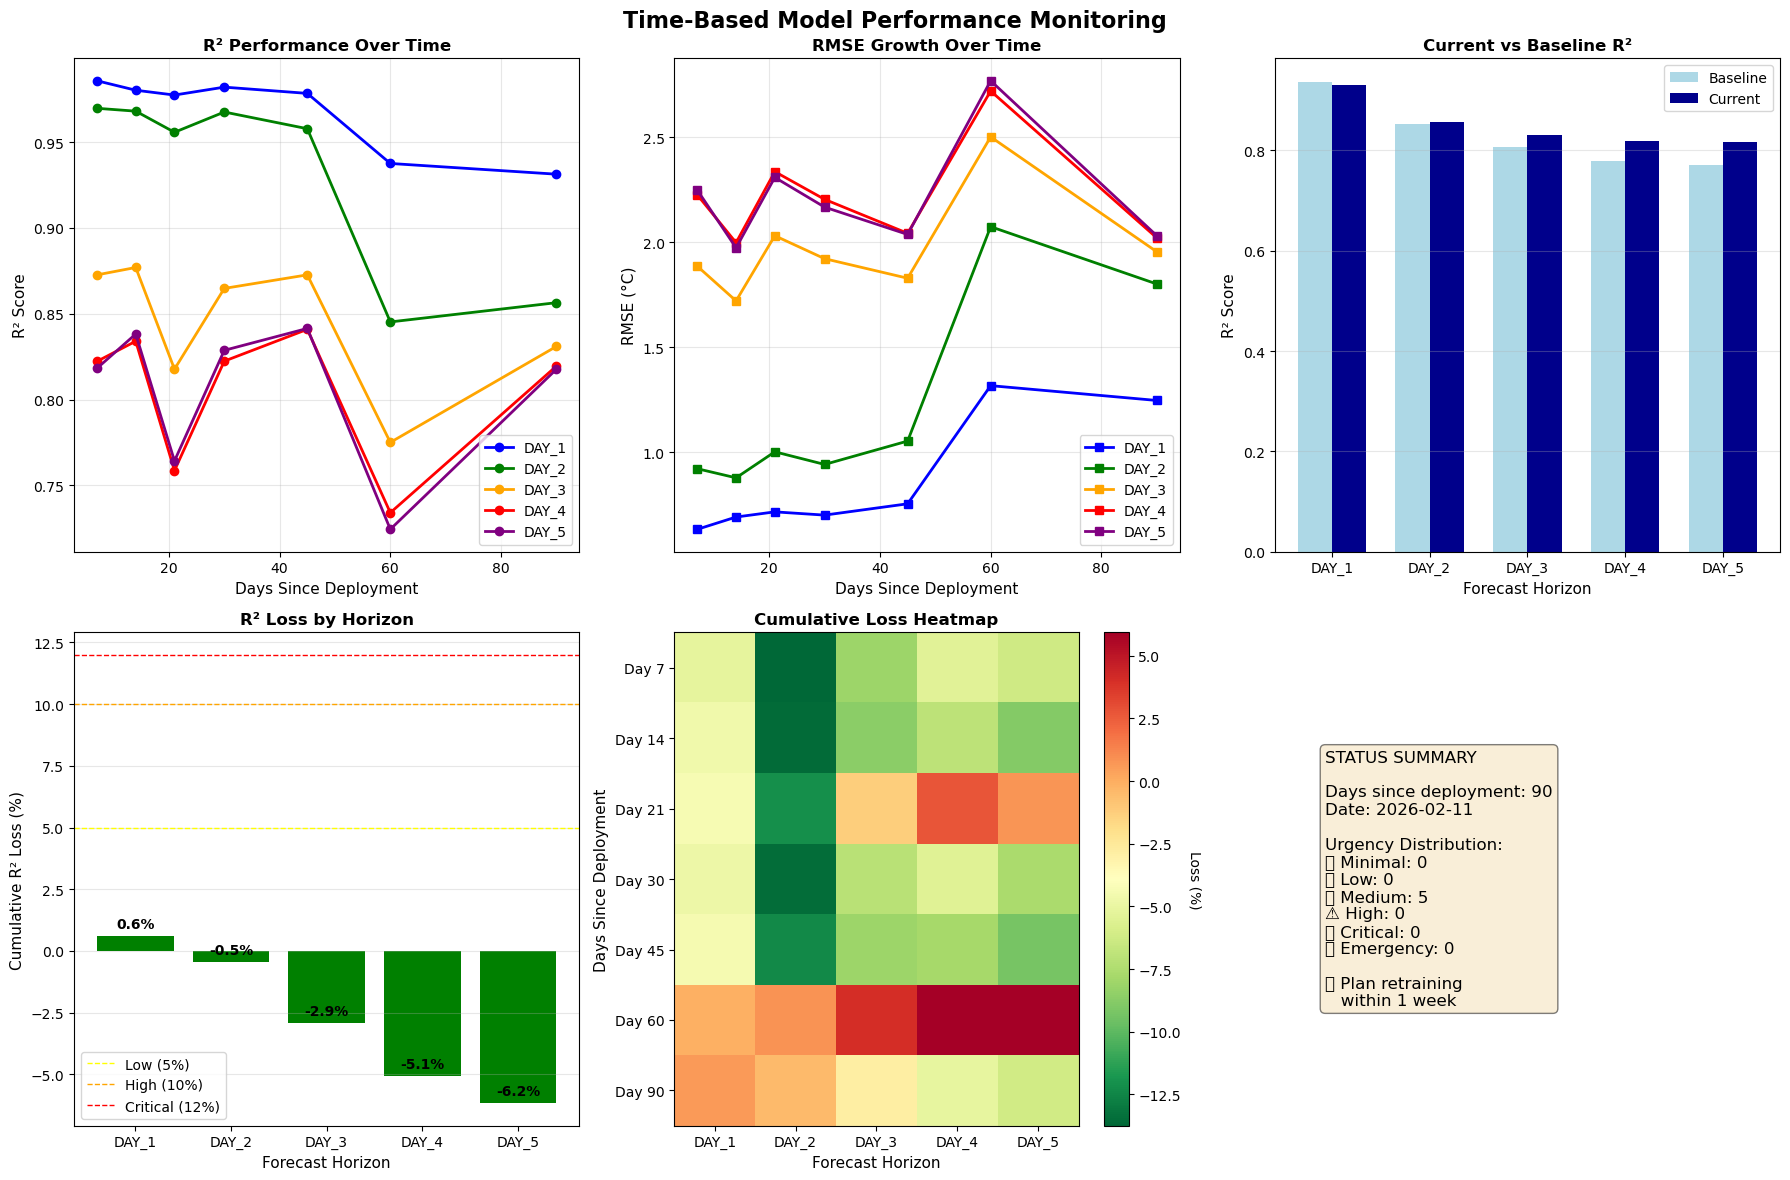

✅ Visualization complete!


In [9]:
# Create comprehensive matplotlib visualizations (FIXED)
print("📊 GENERATING PERFORMANCE DEGRADATION CHARTS")
print("=" * 45)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Time-Based Model Performance Monitoring', fontsize=16, fontweight='bold')

horizon_names = ['day_1', 'day_2', 'day_3', 'day_4', 'day_5']
colors = ['blue', 'green', 'orange', 'red', 'purple']

# 1. R² Over Time (All Horizons)
ax1 = axes[0, 0]
for horizon_idx, horizon_name in enumerate(horizon_names):
    days_list = []
    r2_scores = []
    
    for result in monitoring_results:
        if horizon_name in result['horizon_results']:
            days_list.append(result['monitoring_info']['days_since_training'])
            r2_scores.append(result['horizon_results'][horizon_name]['r2'])
    
    if days_list:
        ax1.plot(days_list, r2_scores, marker='o', linewidth=2, 
                color=colors[horizon_idx], label=horizon_name.upper())

ax1.set_xlabel('Days Since Deployment', fontsize=11)
ax1.set_ylabel('R² Score', fontsize=11)
ax1.set_title('R² Performance Over Time', fontsize=12, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# 2. RMSE Over Time (All Horizons)
ax2 = axes[0, 1]
for horizon_idx, horizon_name in enumerate(horizon_names):
    days_list = []
    rmse_scores = []
    
    for result in monitoring_results:
        if horizon_name in result['horizon_results']:
            days_list.append(result['monitoring_info']['days_since_training'])
            rmse_scores.append(result['horizon_results'][horizon_name]['rmse'])
    
    if days_list:
        ax2.plot(days_list, rmse_scores, marker='s', linewidth=2,
                color=colors[horizon_idx], label=horizon_name.upper())

ax2.set_xlabel('Days Since Deployment', fontsize=11)
ax2.set_ylabel('RMSE (°C)', fontsize=11)
ax2.set_title('RMSE Growth Over Time', fontsize=12, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

# 3. Current vs Baseline R² (Bar Chart)
ax3 = axes[0, 2]
latest_results = monitoring_results[-1]['horizon_results']

horizons_labels = []
current_r2 = []
baseline_r2_vals = []

for horizon_name in horizon_names:
    if horizon_name in latest_results:
        horizons_labels.append(horizon_name.upper())
        current_r2.append(latest_results[horizon_name]['r2'])
        baseline_r2_vals.append(baseline_performance[horizon_name]['r2'])

x = np.arange(len(horizons_labels))
width = 0.35

bars1 = ax3.bar(x - width/2, baseline_r2_vals, width, label='Baseline', color='lightblue')
bars2 = ax3.bar(x + width/2, current_r2, width, label='Current', color='darkblue')

ax3.set_xlabel('Forecast Horizon', fontsize=11)
ax3.set_ylabel('R² Score', fontsize=11)
ax3.set_title('Current vs Baseline R²', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(horizons_labels)
ax3.legend()
ax3.grid(True, axis='y', alpha=0.3)

# 4. Cumulative R² Loss Percentage (Bar Chart)
ax4 = axes[1, 0]
loss_pcts = []

for horizon_name in horizon_names:
    if horizon_name in latest_results:
        loss = latest_results[horizon_name]['cumulative_r2_loss_pct']
        loss_pcts.append(loss)

bars = ax4.bar(horizons_labels, loss_pcts, 
              color=['green' if d < 5 else 'yellow' if d < 8 else 'orange' if d < 10 else 'red' 
                     for d in loss_pcts])

ax4.set_xlabel('Forecast Horizon', fontsize=11)
ax4.set_ylabel('Cumulative R² Loss (%)', fontsize=11)
ax4.set_title('R² Loss by Horizon', fontsize=12, fontweight='bold')
ax4.axhline(y=5, color='yellow', linestyle='--', linewidth=1, label='Low (5%)')
ax4.axhline(y=10, color='orange', linestyle='--', linewidth=1, label='High (10%)')
ax4.axhline(y=12, color='red', linestyle='--', linewidth=1, label='Critical (12%)')
ax4.legend()
ax4.grid(True, axis='y', alpha=0.3)

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.2,
            f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

# 5. Degradation Heatmap
ax5 = axes[1, 1]
degradation_matrix = []

for result in monitoring_results:
    period_losses = []
    for horizon_name in horizon_names:
        if horizon_name in result['horizon_results']:
            loss = result['horizon_results'][horizon_name]['cumulative_r2_loss_pct']
            period_losses.append(loss)
        else:
            period_losses.append(0)
    degradation_matrix.append(period_losses)

days_list = [r['monitoring_info']['days_since_training'] for r in monitoring_results]

im = ax5.imshow(degradation_matrix, cmap='RdYlGn_r', aspect='auto')
ax5.set_xticks(range(len(horizon_names)))
ax5.set_xticklabels([h.upper() for h in horizon_names])
ax5.set_yticks(range(len(days_list)))
ax5.set_yticklabels([f"Day {d}" for d in days_list])
ax5.set_xlabel('Forecast Horizon', fontsize=11)
ax5.set_ylabel('Days Since Deployment', fontsize=11)
ax5.set_title('Cumulative Loss Heatmap', fontsize=12, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax5)
cbar.set_label('Loss (%)', rotation=270, labelpad=15)

# 6. Status Summary (FIXED)
ax6 = axes[1, 2]
ax6.axis('off')

latest_decisions = monitoring_results[-1]['retraining_decisions']
latest_info = monitoring_results[-1]['monitoring_info']

# Count by urgency
urgency_counts = {'MINIMAL': 0, 'LOW': 0, 'MEDIUM': 0, 'HIGH': 0, 'CRITICAL': 0, 'EMERGENCY': 0}
for decision in latest_decisions.values():
    urgency = decision['timeline']['urgency']
    urgency_counts[urgency] += 1

# Create summary text
summary_text = "STATUS SUMMARY\n\n"
summary_text += f"Days since deployment: {latest_info['days_since_training']}\n"
summary_text += f"Date: {latest_info['calendar_date'].strftime('%Y-%m-%d')}\n\n"
summary_text += "Urgency Distribution:\n"
summary_text += f"✅ Minimal: {urgency_counts['MINIMAL']}\n"
summary_text += f"🟡 Low: {urgency_counts['LOW']}\n"
summary_text += f"🟠 Medium: {urgency_counts['MEDIUM']}\n"
summary_text += f"⚠️ High: {urgency_counts['HIGH']}\n"
summary_text += f"🔴 Critical: {urgency_counts['CRITICAL']}\n"
summary_text += f"🚨 Emergency: {urgency_counts['EMERGENCY']}\n\n"

if urgency_counts['EMERGENCY'] > 0 or urgency_counts['CRITICAL'] > 0:
    summary_text += "⚠️ IMMEDIATE RETRAINING\n   REQUIRED!"
elif urgency_counts['HIGH'] > 0:
    summary_text += "⚠️ Retraining recommended\n   within 3 days"
elif urgency_counts['MEDIUM'] > 0:
    summary_text += "🟠 Plan retraining\n   within 1 week"
elif urgency_counts['LOW'] > 0:
    summary_text += "🟡 Monitor closely\n   Retrain in 2 weeks"
else:
    summary_text += "✅ All models stable\n   Routine monitoring"

ax6.text(0.1, 0.5, summary_text, fontsize=12, verticalalignment='center',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("✅ Visualization complete!")

## 📚 Understanding Multi-Horizon Monitoring Metrics

### 🎯 What is R² (R-squared)?
**R²** measures how well the model explains temperature variations (scale: 0 to 1).

- **R² = 0.95**: Model explains 95% of temperature patterns (Excellent)
- **R² = 0.85**: Model explains 85% of temperature patterns (Good)
- **R² < 0.70**: Model explains less than 70% (Poor)

**Why it matters**: Higher R² means predictions are more reliable and accurate.

---

### 📏 What is RMSE (Root Mean Square Error)?
**RMSE** measures the average prediction error in degrees Celsius.

- **RMSE < 1.5°C**: Excellent accuracy for daily forecasts
- **RMSE 1.5-2.5°C**: Good accuracy
- **RMSE > 3.0°C**: Poor accuracy - retraining needed

**Why it matters**: Lower RMSE means temperature predictions are closer to reality.

---

### 📉 What is Performance Degradation?
**Performance degradation** shows how much worse the model performs compared to baseline.

**Calculation**: `|((Current R² - Baseline R²) / Baseline R²)| × 100`

**Example**:
- Baseline R² = 0.95, Current R² = 0.86
- Degradation = |((0.86 - 0.95) / 0.95)| × 100 = **9.5%**

---

### 🔢 Multi-Horizon Monitoring
Unlike daily models that predict a single outcome, hourly-enhanced models predict **5 different horizons**:

- **Day 1**: Tomorrow's temperature (most accurate)
- **Day 2**: 2 days ahead
- **Day 3**: 3 days ahead  
- **Day 4**: 4 days ahead
- **Day 5**: 5 days ahead (least accurate)

**Each horizon degrades independently**, so we monitor all 5 separately!

---

### ⏰ When Should We Retrain? (Per Horizon)

Based on **R² degradation thresholds**:

1. **< 5% degradation**: ✅ Model stable - routine monitoring
2. **5-8% degradation**: 🟡 Early warning - plan retraining in 3 days
3. **8-10% degradation**: 🟠 Moderate concern - retrain within 2 days
4. **10-12% degradation**: ⚠️ High priority - retrain within 1 day
5. **≥ 12% degradation**: 🚨 Critical - retrain immediately

---

### 🎯 Why Multi-Horizon Monitoring is Important

1. **Early Detection**: Day 1 degrading? All horizons need attention
2. **Targeted Retraining**: Maybe only Day 4-5 need updates
3. **Quality Assurance**: Ensure consistent accuracy across all forecast days
4. **Business Impact**: Different horizons serve different use cases:
   - Day 1-2: Critical for immediate planning
   - Day 3-4: Important for logistics and scheduling
   - Day 5: Useful for general trend awareness

---

**Estimated time**: 2-4 hours (with Optuna optimization)

## 📋 Summary - Multi-Horizon Monitoring System

### 🎯 What This Notebook Delivers

A **production-ready multi-horizon monitoring system** for 5-day temperature forecasting that:

1. ✅ Tracks R² and RMSE degradation across all 5 forecast horizons (Day 1-5)
2. ✅ Provides per-horizon retraining recommendations with specific deadlines
3. ✅ Visualizes performance trends through interactive dashboards
4. ✅ Identifies which forecast days need urgent attention
5. ✅ Supports both individual horizon and system-wide health assessment

---

### 🔍 Key Components

| Component | Purpose |
|-----------|---------|
| **MultiHorizonModelMonitor** | Tracks 5 models simultaneously with unified thresholds |
| **Multi-Period Evaluation** | Monitors performance across time (e.g., monthly periods) |
| **Status Dashboard** | Shows current metrics for all 5 horizons at once |
| **Interactive Charts** | Plotly dashboard with R², RMSE, gauges, and heatmaps |
| **Static Visualizations** | Matplotlib charts for detailed analysis |
| **Retraining Timeline** | Per-horizon recommendations with business impact |

---

### ⏰ Retraining Decision Framework (Per Horizon)

**Thresholds** (based on R² degradation):

- **< 5%**: ✅ Routine monitoring (7 days)
- **5-8%**: 🟡 Plan retraining (3 days)
- **8-10%**: 🟠 Urgent retraining (2 days)
- **10-12%**: ⚠️ High priority (1 day)
- **≥ 12%**: 🚨 Critical - immediate action

**System-wide rules**:
- If **Day 1** degrades ≥10%, all horizons need attention
- If **≥3 horizons** exceed 8%, schedule full retraining
- If **any horizon** reaches emergency (≥15%), stop predictions

---

### 🎬 How to Use

1. **Run weekly/monthly**: Execute this notebook to track model health
2. **Check dashboard**: Review gauges, time-series, and heatmap
3. **Read recommendations**: Each horizon gets specific action items
4. **Follow timeline**: Act according to urgency levels
5. **Retrain systematically**: Use notebooks 01→02→03 to update models

---

### 📊 What Makes This Different from Daily Monitoring?

| Aspect | Daily Model Monitoring | Hourly Multi-Horizon Monitoring |
|--------|----------------------|--------------------------------|
| **Models Tracked** | 1 model | 5 models (one per day) |
| **Complexity** | Simple single-target | Complex multi-output |
| **Degradation Pattern** | Uniform decline | Horizon-specific decline |
| **Retraining Decision** | Binary (yes/no) | Per-horizon prioritization |
| **Business Impact** | General forecasting | Day-specific use cases |

---

### 🔄 Integration with Training Pipeline

This monitoring notebook **assumes models trained in notebook 03**:

```
notebooks_hourly/
├── 03_model_training_hourly.ipynb  ← Trains 5 models with Optuna
└── 04_model_monitoring_retraining.ipynb  ← YOU ARE HERE
```

**Files used**:
- `../models/hourly_trained/model_metadata.json` - Baseline performance
- `../models/hourly_trained/best_model_day_*.joblib` - Trained models
- `../models/hourly_trained/scaler_5day.joblib` - Feature scaler
- `../models/hourly_trained/feature_columns_5day.joblib` - Feature names

---

### ✅ Validation Checklist

Before deploying this monitoring system:

- ✅ Notebook 03 successfully trained all 5 models
- ✅ Baseline metrics are realistic (R² > 0.80, RMSE < 2.5°C)
- ✅ Monitoring data covers recent time periods
- ✅ All 5 horizons are evaluated in each monitoring period
- ✅ Degradation thresholds align with business requirements
- ✅ Alert system is configured (email, Slack, etc.)

---

### 📌 Key Takeaway

**Model performance degrades over time due to:**
- Weather pattern shifts (seasonality)
- Climate change effects
- Data distribution drift
- Sensor calibration changes

**This monitoring system ensures you catch degradation early and maintain forecast quality!**